In [1]:
#imports
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading data
real_df = pd.read_csv('lung_cancer_dataset_2.csv')
synthetic_df = pd.read_csv('survey_lung_cancer_synthetic_balanced.csv')

real_df.columns = real_df.columns.str.strip()
synthetic_df.columns = synthetic_df.columns.str.strip()

print(real_df.columns.tolist())
print(synthetic_df.columns.tolist())

['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING', 'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN', 'LUNG_CANCER']
['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING', 'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN', 'LUNG_CANCER']


In [3]:
#splitting real data by class
real_no  = real_df[real_df['LUNG_CANCER'] == 'NO'].reset_index(drop=True)
real_yes = real_df[real_df['LUNG_CANCER'] == 'YES'].reset_index(drop=True)

real_no_train  = real_no.iloc[:15]
real_no_test   = real_no.iloc[15:]

real_yes_train = real_yes.iloc[:15]
real_yes_test  = real_yes.iloc[15:]

print(f"Real NO  — train: {len(real_no_train)}, test: {len(real_no_test)}")
print(f"Real YES — train: {len(real_yes_train)}, test: {len(real_yes_test)}")

Real NO  — train: 15, test: 24
Real YES — train: 15, test: 255


In [4]:
#building train and test sets
train_df = pd.concat([
    synthetic_df,
    real_no_train,
    real_yes_train
], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

test_df = pd.concat([
    real_no_test,
    real_yes_test
], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Train size: {len(train_df)}")
print(f"NO cancer:  {(train_df['LUNG_CANCER'] == 'NO').sum()}")
print(f"YES cancer: {(train_df['LUNG_CANCER'] == 'YES').sum()}")
print(f"\nTest size: {len(test_df)}")
print(f"NO cancer:  {(test_df['LUNG_CANCER'] == 'NO').sum()}")
print(f"YES cancer: {(test_df['LUNG_CANCER'] == 'YES').sum()}")

Train size: 648
NO cancer:  324
YES cancer: 324

Test size: 279
NO cancer:  24
YES cancer: 255


In [5]:
#encoding columns
column = ['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
       'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE', 'ALLERGY',
       'WHEEZING', 'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
       'SWALLOWING DIFFICULTY', 'CHEST PAIN']

le = LabelEncoder()

def prepare(df):
    d = df.copy()
    d.columns = d.columns.str.strip()
    for col in column:
        if col in d.columns:
            d[col] = le.fit_transform(d[col].astype(str))
    d = pd.get_dummies(d, drop_first=True)
    return d

train_enc = prepare(train_df)
test_enc  = prepare(test_df)

test_enc = test_enc.reindex(columns=train_enc.columns, fill_value=0)

X = train_enc.drop(columns=['LUNG_CANCER_YES']).values
y = train_enc['LUNG_CANCER_YES'].values

X_test_real  = test_enc.drop(columns=['LUNG_CANCER_YES']).values
y_test_real  = test_enc['LUNG_CANCER_YES'].values

#scaling and converting to tensors

scaler = StandardScaler()
X_train = scaler.fit_transform(X)
X_test  = scaler.transform(X_test_real)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y,            dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test_real,  dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

In [6]:
#building model
class MixedFNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64,32),
            nn.ReLU(),

            nn.Linear(32,1)
        )

    def forward(self, x):
        return self.network(x)

input_dim = X_train.shape[1]
model = MixedFNN(input_dim)
print(model)

#training model
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

losses = []

for epoch in range(3000):
    model.train()
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/3500 — Loss: {avg_loss:.4f}")

MixedFNN(
  (network): Sequential(
    (0): Linear(in_features=15, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)
Epoch 100/3500 — Loss: 0.2804
Epoch 200/3500 — Loss: 0.2483
Epoch 300/3500 — Loss: 0.1862
Epoch 400/3500 — Loss: 0.1605
Epoch 500/3500 — Loss: 0.1272
Epoch 600/3500 — Loss: 0.0970
Epoch 700/3500 — Loss: 0.1010
Epoch 800/3500 — Loss: 0.0727
Epoch 900/3500 — Loss: 0.0482
Epoch 1000/3500 — Loss: 0.0563
Epoch 1100/3500 — Loss: 0.0499
Epoch 1200/3500 — Loss: 0.0417
Epoch 1300/3500 — Loss: 0.0443
Epoch 1400/3500 — Loss: 0.0401
Epoch 1500/3500 — Loss: 0.0309
Epoch 1600/3500 — Loss: 0.0237
Epoch 1700/3500 — Loss: 0.0314
Epoch 1800/3500 — Loss: 0.0256
Epoch 1900/3500 — Loss: 0.0253
Epoch 2000/3

Train MAE : 0.00
Test  MAE : 0.15
Gap       : 0.15


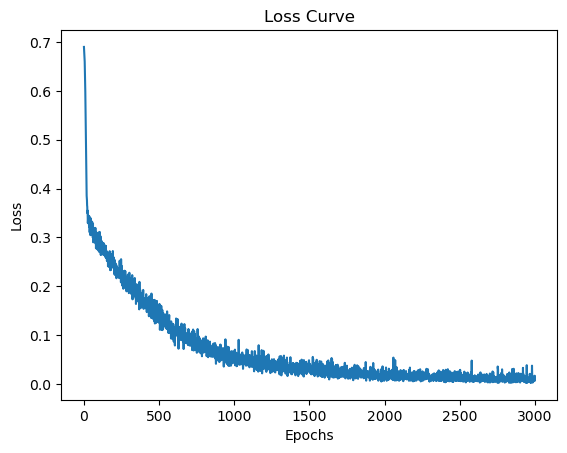

In [7]:
#checking for overfitting
model.eval()
with torch.no_grad():
    tr_preds = torch.sigmoid(model(X_train_t)).numpy().flatten()
    te_preds = torch.sigmoid(model(X_test_t)).numpy().flatten()

tr_mae = np.abs(tr_preds - y).mean()
te_mae = np.abs(te_preds - y_test_real).mean()

print(f"Train MAE : {tr_mae:.2f}")
print(f"Test  MAE : {te_mae:.2f}")
print(f"Gap       : {te_mae - tr_mae:.2f}")

plt.plot(losses)
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [8]:
#evaluating model
model.eval()
y_pred_proba = torch.sigmoid(model(X_test_t)).detach().numpy().flatten()
y_true = y_test_t.numpy().flatten()
y_pred_class = (y_pred_proba > 0.5).astype(int)

test_acc = (y_pred_class == y_true).mean()

print(f"Accuracy: {test_acc:.4f}")
print(f"F1 Score: {f1_score(y_true, y_pred_class):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_true, y_pred_proba):.4f}")
print(classification_report(y_true, y_pred_class, target_names=['No Cancer', 'Cancer']))
print(test_enc['LUNG_CANCER_YES'].value_counts())

Accuracy: 0.8495
F1 Score: 0.9106
AUC-ROC:  0.9695
              precision    recall  f1-score   support

   No Cancer       0.36      0.96      0.52        24
      Cancer       1.00      0.84      0.91       255

    accuracy                           0.85       279
   macro avg       0.68      0.90      0.72       279
weighted avg       0.94      0.85      0.88       279

LUNG_CANCER_YES
True     255
False     24
Name: count, dtype: int64


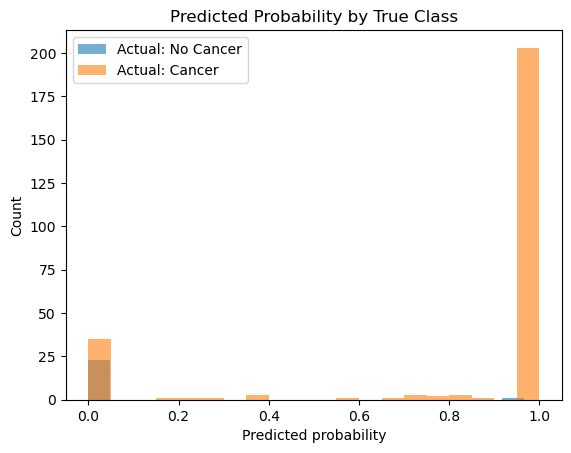

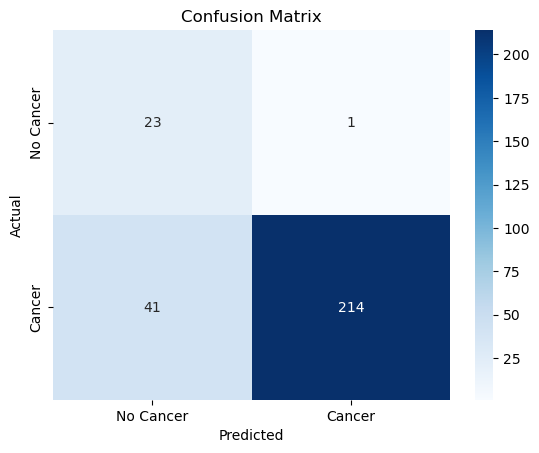

In [9]:
#predicted probability distribution
plt.figure()
plt.hist(y_pred_proba[y_true == 0], bins=20, alpha=0.6, label='Actual: No Cancer')
plt.hist(y_pred_proba[y_true == 1], bins=20, alpha=0.6, label='Actual: Cancer')
plt.xlabel('Predicted probability')
plt.ylabel('Count')
plt.title('Predicted Probability by True Class')
plt.legend()
plt.show()

#confusion matrix
cm = confusion_matrix(y_true, y_pred_class)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Cancer', 'Cancer'],
            yticklabels=['No Cancer', 'Cancer'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

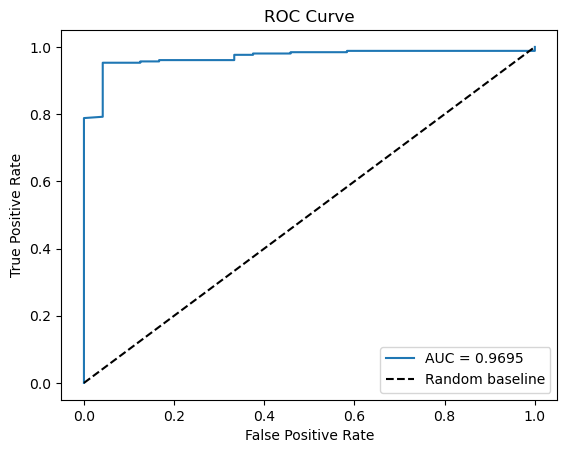

In [10]:
#ROC curve
fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
auc_score   = roc_auc_score(y_true, y_pred_proba)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()